# **END-TO-END ML PIPELINE**
# **Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.**

---



In [113]:
# ============================================================
# 1.0 IMPORT LIBRARIES#
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid")

print("1.0 Passed ✓")


1.0 Passed ✓


In [114]:
# ============================================================
# 2.0 DATA LOADING
# ============================================================

df = pd.read_csv(
    "tesla_deliveries_dataset_2015_2025.csv"
)

print("Dataset Shape :", df.shape)

display(df.head())

print("2.0 Passed ✓")


Dataset Shape : (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


2.0 Passed ✓


# **Data Preprocessing**

In [115]:
# ============================================================
# 3.1 DATASET INSPECTION
# ============================================================

print(df.info())

display(df.describe())

print("3.1 Passed ✓")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


3.1 Passed ✓


In [116]:
# ============================================================
# 3.2 MISSING VALUES
# ============================================================

num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = df.select_dtypes(
    include=['object']
).columns

for col in num_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )

for col in cat_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

print(df.isnull().sum())

print("3.2 Passed ✓")

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
3.2 Passed ✓


In [117]:
# ============================================================
# 3.3 DUPLICATE REMOVAL
# ============================================================

before = len(df)

df.drop_duplicates(
    inplace=True
)

after = len(df)

print(
    "Duplicates Removed :",
    before-after
)

print("3.3 Passed ✓")

Duplicates Removed : 0
3.3 Passed ✓


In [118]:
# ============================================================
# 3.4 DATE FORMATTING
# ============================================================

df['Date'] = pd.to_datetime(
    df[['Year','Month']]
    .assign(DAY=1)
)

display(
    df[['Year','Month','Date']].head()
)

print("3.4 Passed ✓")


,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


3.4 Passed ✓


In [119]:
# ============================================================
# 4.1 DATASET SUMMARY
# ============================================================

print(df.shape)

display(df.head())

print("4.1 Passed ✓")

(2640, 13)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


4.1 Passed ✓


# **Exploratory Data Analysis**

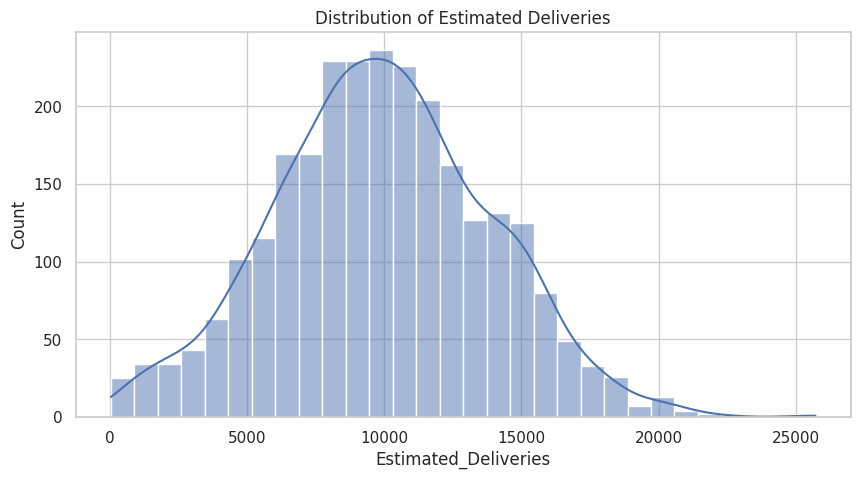

4.2 Passed ✓


In [120]:
# ============================================================
# 4.2 TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='Estimated_Deliveries',
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Estimated Deliveries"
)

plt.show()

print("4.2 Passed ✓")

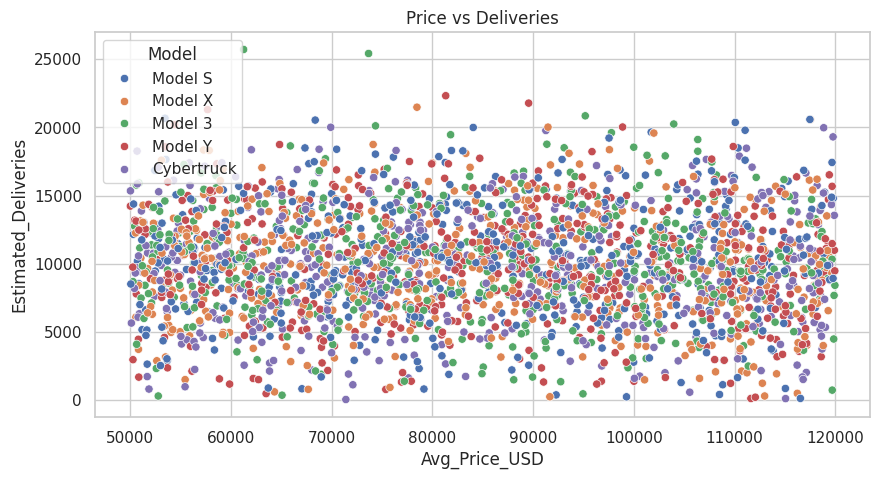

4.3 Passed ✓


In [121]:
# ============================================================
# 4.3 PRICE VS SALES
# ============================================================

plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x='Avg_Price_USD',
    y='Estimated_Deliveries',
    hue='Model'
)

plt.title(
    "Price vs Deliveries"
)

plt.show()

print("4.3 Passed ✓")

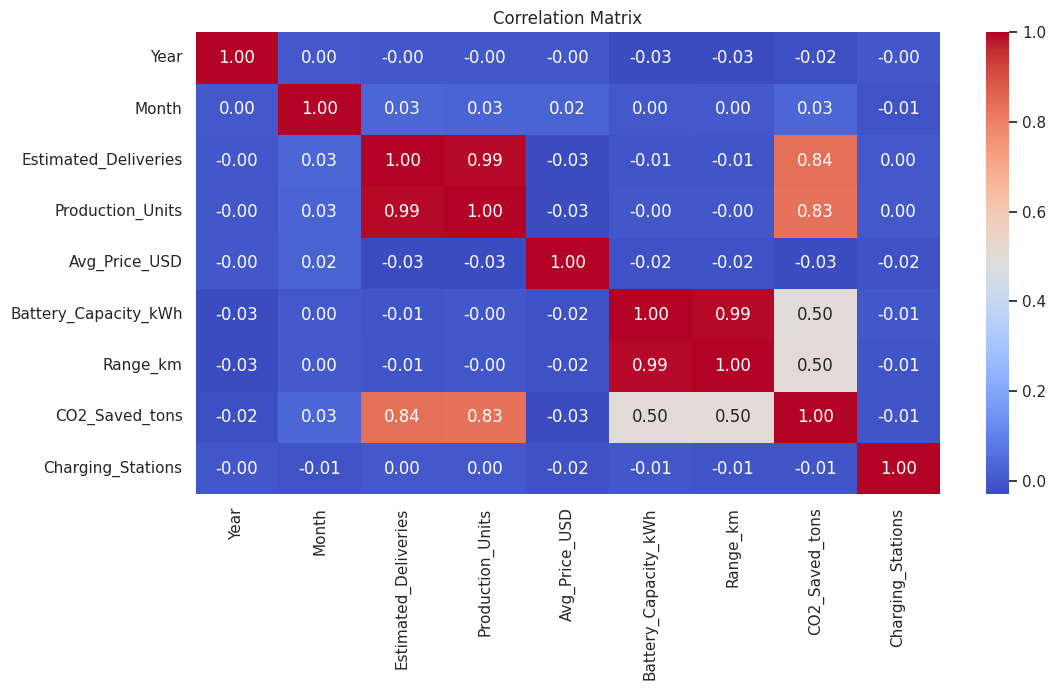

4.4 Passed ✓


In [122]:
# ============================================================
# 4.4 CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    "Correlation Matrix"
)

plt.show()

print("4.4 Passed ✓")


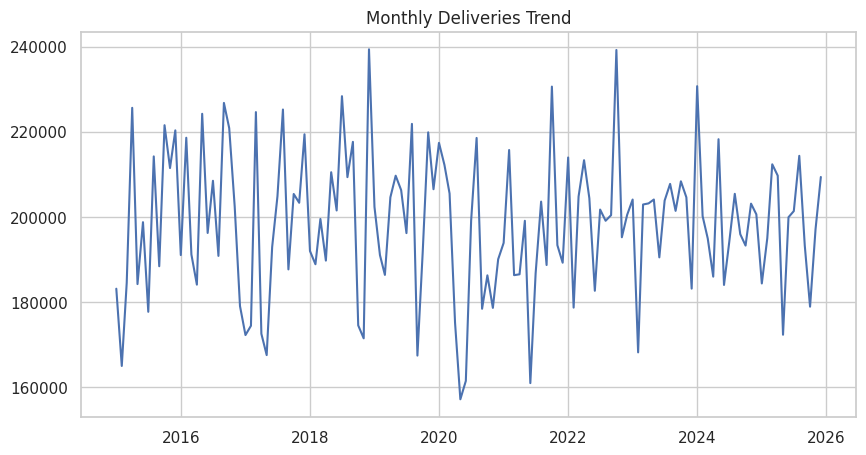

4.5 Passed ✓


In [123]:
# ============================================================
# 4.5 MONTHLY SALES TREND
# ============================================================

monthly_deliveries = (

    df.groupby('Date')
      ['Estimated_Deliveries']
      .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_deliveries.index,
    monthly_deliveries.values
)

plt.title(
    "Monthly Deliveries Trend"
)

plt.show()

print("4.5 Passed ✓")

# **Feature Engineering**

In [124]:
# ============================================================
# 5.1 PRICE PER KM
# ============================================================

df['Price_per_km'] = (

    df['Avg_Price_USD']

    /

    (df['Range_km'] + 1)
)

print("5.1 Passed ✓")

5.1 Passed ✓


In [125]:
# ============================================================
# 5.2 RANGE PER KWH
# ============================================================

df['Range_per_kWh'] = (

    df['Range_km']

    /

    (df['Battery_Capacity_kWh'] + 1)
)

print("5.2 Passed ✓")

5.2 Passed ✓


In [126]:
# ============================================================
# 5.3 CYCLICAL MONTH FEATURES
# ============================================================

df['Month_Sin'] = np.sin(
    2*np.pi*df['Month']/12
)

df['Month_Cos'] = np.cos(
    2*np.pi*df['Month']/12
)

print("5.3 Passed ✓")


5.3 Passed ✓


In [127]:
# ============================================================
# 6.1 FEATURE SELECTION
# ============================================================

target = 'Estimated_Deliveries'

features = [

    'Region',
    'Model',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Price_per_km',
    'Range_per_kWh',
    'Month_Sin',
    'Month_Cos'
]

X = df[features]

y = df[target]

print("6.1 Passed ✓")

6.1 Passed ✓


In [128]:
# ============================================================
# 6.2 TRAIN TEST SPLIT
# ============================================================

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print(X_train.shape)
print(X_test.shape)

print("6.2 Passed ✓")

(2112, 10)
(528, 10)
6.2 Passed ✓


In [129]:
# ============================================================
# 6.3 PREPROCESSING PIPELINE
# ============================================================

numeric_features = [

    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Price_per_km',
    'Range_per_kWh',
    'Month_Sin',
    'Month_Cos'
]

categorical_features = [

    'Region',
    'Model'
]
preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            StandardScaler(),
            numeric_features
        ),

        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

print("6.3 Passed ✓")

6.3 Passed ✓


# **Regression Modeling**

In [130]:
# ============================================================
# 7.0 Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression R²:", round(lr_r2,4))
print("7.0 Passed ✓")

Linear Regression R²: 0.9419
7.0 Passed ✓


In [131]:
# ============================================================
# 7.1 Ridge Regression
# ============================================================
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

ridge_pred = ridge_pipeline.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression R²:", round(ridge_r2,4))
print("7.1 Passed ✓")

Ridge Regression R²: 0.9418
7.1 Passed ✓


In [132]:
# ============================================================
# 7.2 Lasso Regression
# ============================================================
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.01))
])

lasso_pipeline.fit(X_train, y_train)

lasso_pred = lasso_pipeline.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression R²:", round(lasso_r2,4))
print("7.2 Passed ✓")

Lasso Regression R²: 0.9416
7.2 Passed ✓


In [133]:
# ============================================================
# 7.3 MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'R2': [
        lr_r2,
        ridge_r2,
        lasso_r2
    ]
})

comparison = comparison.sort_values(by='R2', ascending=False)

display(comparison)

print("7.3 Passed ✓")

,Model,R2
0,Linear Regression,0.941865
1,Ridge Regression,0.941793
2,Lasso Regression,0.941649


7.3 Passed ✓


In [134]:
# ============================================================
# 7.4 Best Modal
# ============================================================
models = {
    "Linear": lr_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline
}

scores = {
    "Linear": lr_r2,
    "Ridge": ridge_r2,
    "Lasso": lasso_r2
}

best_name = max(scores, key=scores.get)

best_model = models[best_name]

print("Best Model:", best_name)
print("Best R²:", scores[best_name])
print("7.4 Passed ✓")

Best Model: Linear
Best R²: 0.941865451501918
7.4 Passed ✓


# **Hyperparameter Tuning**

In [135]:
# ============================================================
# 8.0 RIDGE REGRESSION + HYPERPARAMETER TUNING
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('model', Ridge())
])

ridge_param_grid = {

    'model__alpha': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

ridge_grid = GridSearchCV(

    ridge_pipeline,

    ridge_param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1
)

ridge_grid.fit(
    X_train,
    y_train
)

ridge_best = ridge_grid.best_estimator_

ridge_pred = ridge_best.predict(
    X_test
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print("Best Alpha :", ridge_grid.best_params_)
print("Ridge R² :", round(ridge_r2,4))

print("8.0 Passed ✓")

Best Alpha : {'model__alpha': 1}
Ridge R² : 0.9418
8.0 Passed ✓


In [136]:
# ============================================================
# 8.1 LASSO REGRESSION + HYPERPARAMETER TUNING
# ============================================================

from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('model', Lasso(max_iter=10000))
])

lasso_param_grid = {

    'model__alpha': [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10
    ]
}

lasso_grid = GridSearchCV(

    lasso_pipeline,

    lasso_param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1
)

lasso_grid.fit(
    X_train,
    y_train
)

lasso_best = lasso_grid.best_estimator_

lasso_pred = lasso_best.predict(
    X_test
)

lasso_r2 = r2_score(
    y_test,
    lasso_pred
)

print("Best Alpha :", lasso_grid.best_params_)
print("Lasso R² :", round(lasso_r2,4))

print("8.1 Passed ✓")

Best Alpha : {'model__alpha': 10}
Lasso R² : 0.9421
8.1 Passed ✓


In [137]:
# ============================================================
# 8.2 MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    'Model': [

        'Linear Regression',

        'Ridge Regression',

        'Lasso Regression'
    ],

    'R2': [

        lr_r2,

        ridge_r2,

        lasso_r2
    ]
})

comparison = comparison.sort_values(

    by='R2',

    ascending=False
)

display(comparison)

print("8.2 Passed ✓")

,Model,R2
2,Lasso Regression,0.942150
0,Linear Regression,0.941865
1,Ridge Regression,0.941793


8.2 Passed ✓


In [138]:
# ============================================================
# 8.3 BEST MODEL SELECTION
# ============================================================

models = {

    'Linear Regression':
        lr_pipeline,

    'Ridge Regression':
        ridge_best,

    'Lasso Regression':
        lasso_best
}

scores = {

    'Linear Regression':
        lr_r2,

    'Ridge Regression':
        ridge_r2,

    'Lasso Regression':
        lasso_r2
}

best_name = max(
    scores,
    key=scores.get
)

best_model = models[
    best_name
]

print("Best Model :", best_name)

print(
    "Best R² :",
    round(scores[best_name],4)
)

print("8.3 Passed ✓")

Best Model : Lasso Regression
Best R² : 0.9421
8.3 Passed ✓


In [139]:
# ============================================================
# 8.4 BEST MODEL EVALUATION
# ============================================================

predictions = best_model.predict(
    X_test
)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        predictions
    )
)

mae = mean_absolute_error(

    y_test,

    predictions
)

r2 = r2_score(

    y_test,

    predictions
)

print("RMSE :", round(rmse,2))

print("MAE :", round(mae,2))

print("R² :", round(r2,4))

print("8.4 Passed ✓")

RMSE : 928.62
MAE : 654.85
R² : 0.9421
8.4 Passed ✓


# **Model Evaluation**

In [140]:
# ============================================================
# 8.5 GRID SEARCH CV (BEST MODEL - LASSO REGRESSION)
# ============================================================

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Lasso pipeline
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000))
])

# Hyperparameter grid
param_grid = {
    'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

# Grid Search CV
grid = GridSearchCV(
    lasso_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best model
lasso_best_model = grid.best_estimator_

# Predictions
lasso_pred = lasso_best_model.predict(X_test)

# Evaluation
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Best Parameters:", grid.best_params_)
print("Lasso RMSE:", round(lasso_rmse, 2))
print("Lasso MAE:", round(lasso_mae, 2))
print("Lasso R²:", round(lasso_r2, 4))

print("8.5 Passed ✓")

Best Parameters: {'regressor__alpha': 10}
Lasso RMSE: 928.62
Lasso MAE: 654.85
Lasso R²: 0.9421
8.5 Passed ✓


In [141]:
# ============================================================
# 8.6 ACTUAL VS PREDICTED
# ============================================================

results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

display(results_df.head(10))
print("8.6 Passed ✓")

,Actual,Predicted
0,6991,8105.654422
1,9326,9296.230759
2,9061,9199.668330
3,8951,8935.502350
4,8707,8950.284068
5,11351,11144.544207
6,14193,13409.041190
7,15156,14621.653831
8,9915,9861.372358
9,7642,8060.718223


8.6 Passed ✓


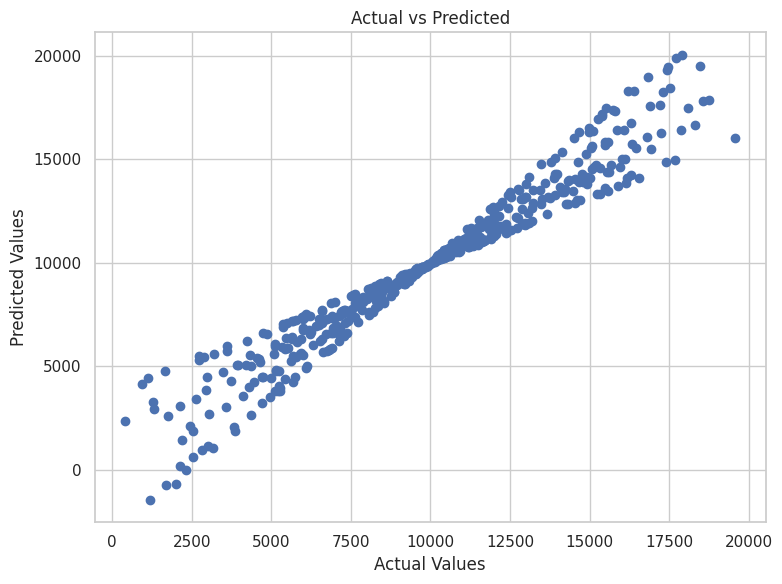

8.7 Passed ✓


In [142]:
# ============================================================
# 8.7 ACTUAL VS PREDICTED PLOT
# ============================================================
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.show()

print("8.7 Passed ✓")

# **Features Importance Analysis**

In [143]:
# ============================================================
# 9.0 FEATURE IMPORTANCE
# ============================================================
# Works for Linear / Ridge / Lasso pipelines
regressor = best_model.named_steps['model']

feature_names = (
    numeric_features +
    list(
        best_model.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_features)
    )
)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': regressor.coef_
})

coef_df['Absolute_Coefficient'] = np.abs(coef_df['Coefficient'])

coef_df = coef_df.sort_values('Absolute_Coefficient', ascending=False)

display(coef_df.head(15))

print("9.0 Passed ✓")

,Feature,Coefficient,Absolute_Coefficient
3,CO2_Saved_tons,4414.161523,4414.161523
2,Range_km,-2195.064963,2195.064963
11,Region_North America,-60.204937,60.204937
1,Battery_Capacity_kWh,-30.101599,30.101599
14,Model_Model S,13.446116,13.446116
0,Avg_Price_USD,-8.238104,8.238104
7,Month_Cos,-1.912263,1.912263
4,Price_per_km,-0.000000,0.000000
5,Range_per_kWh,-0.000000,0.000000
8,Region_Asia,-0.000000,0.000000


9.0 Passed ✓


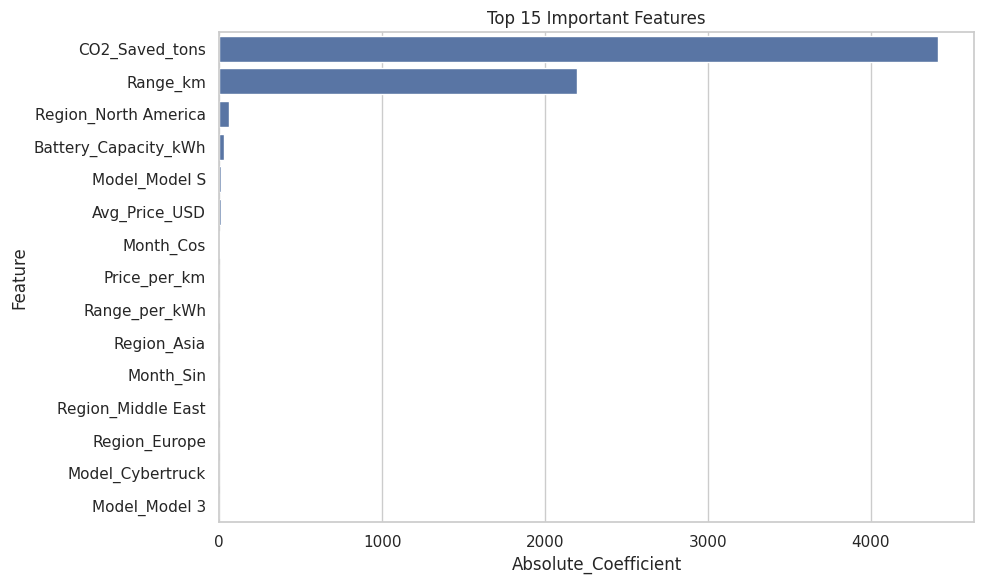

9.1 Passed ✓


In [144]:
# ============================================================
# 9.1 FEATURE IMPORTANCE PLOT
# ============================================================
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df.head(15),
    x='Absolute_Coefficient',
    y='Feature'
)

plt.title("Top 15 Important Features")

plt.tight_layout()
plt.show()

print("9.1 Passed ✓")

# **TIME SERIES Forecasting**

In [145]:
# ============================================================
# 10.0 TIME SERIES AGGREGATION
# ============================================================
ts_data = (
    df.groupby('Date')['Estimated_Deliveries']
    .sum()
    .sort_index()
    .asfreq('MS')
)

train_ts = ts_data[:-12]
test_ts = ts_data[-12:]

print("Train Shape:", train_ts.shape)
print("Test Shape:", test_ts.shape)

print("10.0 Passed ✓")

Train Shape: (120,)
Test Shape: (12,)
10.0 Passed ✓


In [146]:
# ============================================================
# 10.1 ARIMA MODEL
# ============================================================
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train_ts, order=(2,1,2))
results = model.fit()

print(results.summary())
print("9.2 ARIMA Model Trained ✓")
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train_ts, order=(2,1,2))
results = model.fit()

print(results.summary())
print("10.1 ARIMA Model Trained ✓")

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  120
Model:                   ARIMA(2, 1, 2)   Log Likelihood               -1356.903
Date:                  Sun, 31 May 2026   AIC                           2723.806
Time:                          18:56:07   BIC                           2737.702
Sample:                      01-01-2015   HQIC                          2729.449
                           - 12-01-2024                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2721      0.738      0.369      0.712      -1.175       1.719
ar.L2          0.0566      0.137      0.412      0.680      -0.213       0.326
ma.L1         -0.8180      0.753    

In [147]:
# ============================================================
# 10.2 FORECAST GENERATION
# ============================================================
forecast = results.get_forecast(steps=len(test_ts))
forecast_df = forecast.summary_frame()

display(forecast_df.head())

print("10.2 Forecast Generated ✓")

Estimated_Deliveries,mean,mean_se,mean_ci_lower,mean_ci_upper
2025-01-01,199973.213912,18123.464434,164451.876345,235494.551478
2025-02-01,199693.675430,19904.536683,160681.500404,238705.850457
2025-03-01,199580.580331,21200.153593,158029.042822,241132.117839
2025-04-01,199533.997079,22169.644482,156082.292345,242985.701813
2025-05-01,199514.925401,23023.059299,154390.558360,244639.292442


10.2 Forecast Generated ✓


In [148]:
# ============================================================
# 10.3 FORECAST EVALUATION
# ============================================================
forecast_values = forecast_df['mean']

forecast_rmse = np.sqrt(mean_squared_error(test_ts, forecast_values))
forecast_mae = mean_absolute_error(test_ts, forecast_values)

mape = np.mean(np.abs((test_ts - forecast_values) / test_ts)) * 100
accuracy = 100 - mape

print("ARIMA RMSE :", round(forecast_rmse,2))
print("ARIMA MAE  :", round(forecast_mae,2))
print("Accuracy   :", round(accuracy,2), "%")

print("10.3 Evaluation Done ✓")

ARIMA RMSE : 13085.38
ARIMA MAE  : 10535.63
Accuracy   : 94.49 %
10.3 Evaluation Done ✓


# **Forecast Visualization**

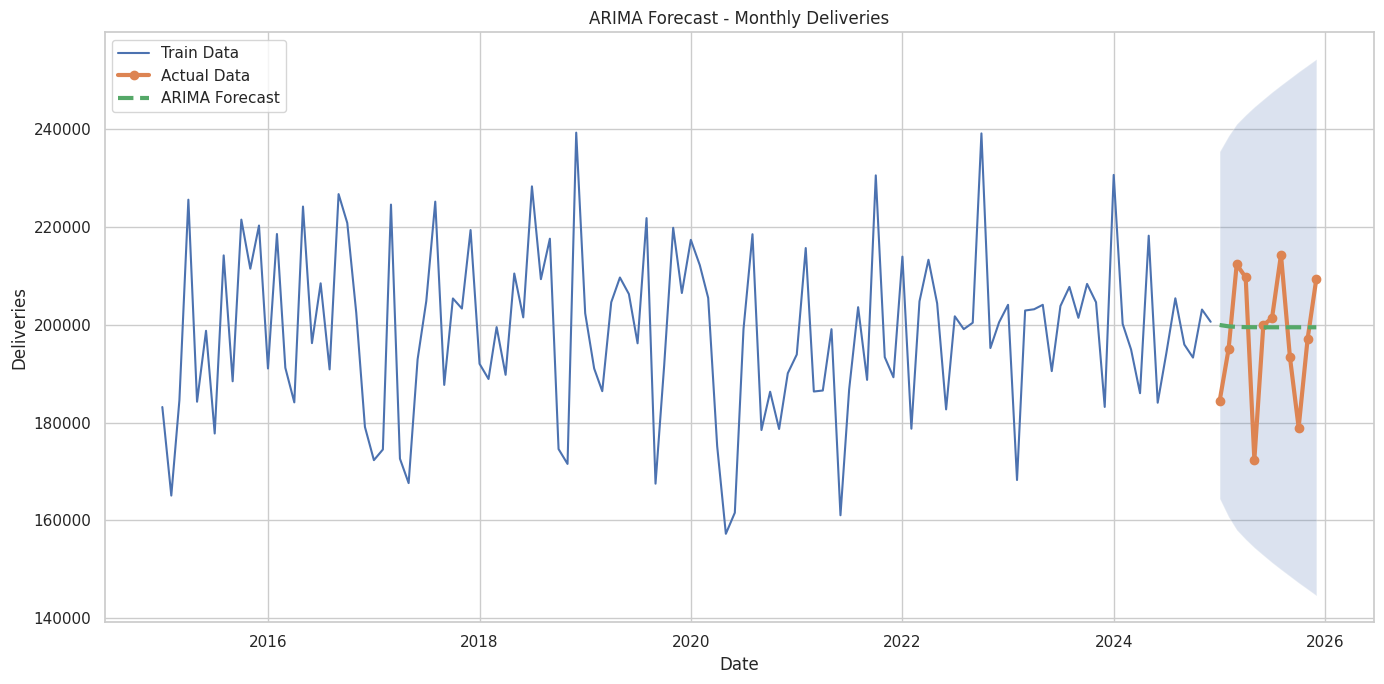

10.4 Visualization Done ✓


In [149]:
# ============================================================
# 10.4 FORECAST VISUALIZATION
# ============================================================
plt.figure(figsize=(14,7))

plt.plot(train_ts.index, train_ts.values, label='Train Data')
plt.plot(test_ts.index, test_ts.values, marker='o', linewidth=3, label='Actual Data')
plt.plot(forecast_df.index, forecast_df['mean'], linestyle='--', linewidth=3, label='ARIMA Forecast')

plt.fill_between(
    forecast_df.index,
    forecast_df['mean_ci_lower'],
    forecast_df['mean_ci_upper'],
    alpha=0.2
)

plt.title("ARIMA Forecast - Monthly Deliveries")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("10.4 Visualization Done ✓")

In [150]:

# ============================================================
# 11.0 PROJECT SUMMARY
# ============================================================
print("""

==========================================================
END-TO-END ML PIPELINE COMPLETED SUCCESSFULLY
==========================================================

✓ Data Loading
✓ Data Preprocessing
    - Missing Value Handling
    - Duplicate Removal
    - Date Formatting

✓ Exploratory Data Analysis
    - Distribution Analysis
    - Correlation Analysis
    - Trend Analysis

✓ Feature Engineering
    - Price_per_km
    - Range_per_kWh
    - Cyclical Features
    - Feature Selection

✓ Regression Modeling
    - Linear Regression
    - Ridge Regression
    - Lasso Regression

✓ Hyperparameter Tuning
    - GridSearchCV (Ridge & Lasso)

✓ Model Evaluation
    - RMSE, MAE, R²

✓ Feature Importance Analysis

✓ Time Series Forecasting
    - ARIMA Model
    - Forecast Generation
    - Evaluation

✓ Forecast Visualization


""")

print("11.0 Passed ✓")



END-TO-END ML PIPELINE COMPLETED SUCCESSFULLY

✓ Data Loading
✓ Data Preprocessing
    - Missing Value Handling
    - Duplicate Removal
    - Date Formatting

✓ Exploratory Data Analysis
    - Distribution Analysis
    - Correlation Analysis
    - Trend Analysis

✓ Feature Engineering
    - Price_per_km
    - Range_per_kWh
    - Cyclical Features
    - Feature Selection

✓ Regression Modeling
    - Linear Regression
    - Ridge Regression
    - Lasso Regression

✓ Hyperparameter Tuning
    - GridSearchCV (Ridge & Lasso)

✓ Model Evaluation
    - RMSE, MAE, R²

✓ Feature Importance Analysis

✓ Time Series Forecasting
    - ARIMA Model
    - Forecast Generation
    - Evaluation

✓ Forecast Visualization



11.0 Passed ✓
